# Diabetic Retinopathy Classification

End-to-end training pipeline for the blended 2015 + 2019 fundus image datasets.
Contains the dataset, model, transforms, splitting logic, training loop, and evaluation.

Run the cells top to bottom; the last cell kicks off training.

## Configuration

Set `MODEL_TYPE` to pick the architecture. Output filenames are derived from it, so
switching here and re-running won't clobber the other model's checkpoints or plots.

In [1]:
# "cnn"    -> FirstCNN, trained from scratch
# "resnet" -> ResNet18, pretrained weights, fine-tuned
MODEL_TYPE = "cnn"

# DataLoader worker processes. The Dataset/transforms/seed_worker now live in the
# importable dr_data.py module (written by the "## Dataset + data module" cell), so
# Windows/macOS 'spawn' workers CAN pickle them -- which is why this is no longer
# forced to 0. Benchmarked on this machine: with the GPU un-throttled (fans up),
# num_workers=2 hid all data-loading behind GPU compute and gave ~2.8x over 0
# (74 -> 205 img/s); 4 was no better. If you hit "OSError [WinError 1455]: paging
# file too small", each spawned worker re-imports torch (~1GB commit) and you ran
# out -- drop to 0 or raise the Windows pagefile. On a strong machine (e.g. an M-series
# Mac) you can push this to 4-8.
NUM_WORKERS = 2

# Input resolution. FirstCNN uses AdaptiveAvgPool so it is resolution-agnostic;
# larger inputs make small lesions (microaneurysms) more visible. The pretrained
# ResNet branch overrides this back to 224 (its ImageNet assumption).
IMG_SIZE = 320

# Loss function: "ce" = plain cross-entropy, "sord" = soft ordinal loss that gives
# partial credit for near-miss grades and penalizes distant mistakes harder.
LOSS_TYPE = "sord"
SORD_SIGMA = 1.0

# Class-imbalance sampling strength for the WeightedRandomSampler. Each sample is
# weighted by 1 / count**SAMPLER_POWER:
#   1.0 = full inverse-frequency (classes fully balanced per batch, but tends to
#         over-predict rare classes on the natural 73%-No-DR validation set)
#   0.5 = square-root middle ground (recommended default)
#   0.0 = natural class distribution (no rebalancing)
SAMPLER_POWER = 0.5

# Mixed precision (Automatic Mixed Precision). Runs the forward/backward in FP16 on
# the GPU's tensor cores. Benchmarked on the 4GB RTX 3050 laptop GPU: ~2-3x faster
# training for FirstCNN at img_size=320 AND ~30% less VRAM, with NO change to image
# resolution, batch size, epochs, model, loss, augmentation, or the random seed
# (cudnn.deterministic stays on, so runs remain reproducible). FP16 introduces tiny
# numerical differences vs FP32; set False for bit-exact FP32. CUDA-only -- ignored
# on CPU/MPS (e.g. a Mac), which run FP32 as before.
# NOTE (measured, do NOT re-add): channels_last and cudnn.benchmark each made THIS
# small model ~4-5x SLOWER on the 3050, so they are deliberately not used.
USE_AMP = True

## Imports and reproducibility

In [2]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from tqdm.auto import tqdm
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    cohen_kappa_score,
)
from sklearn.model_selection import StratifiedShuffleSplit, GroupShuffleSplit

In [3]:
SEED = 42

CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]
DIAGNOSIS_MAP = dict(enumerate(CLASS_NAMES))


def set_global_seed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# NOTE: seed_worker moved to dr_data.py so DataLoader workers can import it under
# 'spawn'. If you change SEED here, change it there too (dr_data.SEED) to match.


def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


set_global_seed()

## Device check

If `torch.version.cuda` prints `None`, torch is a CPU-only build and training will
silently fall back to the CPU — reinstall from the CUDA index before running.

In [4]:
print("torch:", torch.__version__, "| cuda build:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("mps available: ", torch.backends.mps.is_available())
print("selected device:", get_device())

torch: 2.13.0+cu126 | cuda build: 12.6
cuda available: True
mps available:  False
selected device: cuda


## Paths

Resolve the project root regardless of where the notebook is launched from.

In [5]:
project_root = Path.cwd()
if project_root.name in {"model", "data", "notebooks"}:
    project_root = project_root.parent

DATA_ROOT = project_root / "data" / "raw" / "2019_2015_data"
CSV_PATH = DATA_ROOT / "labels" / "traintestLabels15_trainLabels19.csv"

# change this to the directory containing your resized images
# IMAGE_DIR = DATA_ROOT / "resized_traintest15_train19"
IMAGE_DIR = DATA_ROOT / "resized_ben_graham"

print(f"Project root: {project_root}")
print(f"CSV exists:   {CSV_PATH.exists()}")
print(f"Images exist: {IMAGE_DIR.exists()}")

Project root: e:\UMass\AI4ALL-19D
CSV exists:   True
Images exist: True


## Dataset + data module

The `Dataset`, transforms, and `seed_worker` are written to an importable
`dr_data.py` (first cell) and imported back (second cell). This is what lets
`NUM_WORKERS > 0` work on Windows/macOS: spawned DataLoader workers re-import the
module and can find these objects, instead of failing to pickle cell-defined ones.

In [6]:
%%writefile dr_data.py
"""Data-pipeline pieces that DataLoader worker processes must be able to import.

Why this file exists: on Windows/macOS, DataLoader workers use the 'spawn' start
method, which re-imports the entry module in each worker. Objects defined in
notebook cells live in '__main__' and can't be found by spawned workers
(-> "Can't get attribute 'BlindnessDataset' on <module '__main__'>"), which is why
num_workers used to be pinned to 0. Defining them in this importable module lets
num_workers > 0 work, so image decode/augmentation runs in parallel and is hidden
behind GPU compute.

This cell WRITES the file; the next cell imports from it. Keep SEED in sync with the
notebook's SEED if you change it.
"""
import os
import random

import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms

SEED = 42
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


class BlindnessDataset(Dataset):
    def __init__(self, df, image_dir, transform=None, id_col="image", label_col="level"):
        self.ids = df[id_col].values
        self.labels = df[label_col].values
        self.image_dir = image_dir
        self.transform = transform or transforms.ToTensor()

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_name = str(self.ids[idx])

        # Dynamically discover the file extension (.jpeg, .png, or .jpg)
        if not img_name.endswith((".png", ".jpeg", ".jpg")):
            img_path = os.path.join(self.image_dir, f"{img_name}.jpeg")
            if not os.path.exists(img_path):
                img_path = os.path.join(self.image_dir, f"{img_name}.png")
                if not os.path.exists(img_path):
                    img_path = os.path.join(self.image_dir, f"{img_name}.jpg")
        else:
            img_path = os.path.join(self.image_dir, img_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except FileNotFoundError:
            raise FileNotFoundError(f"Missing image: {img_path}. Verify image_dir path.")

        image = self.transform(image)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return image, label


def get_transforms(img_size=320):
    # Fundus images have no canonical orientation, so flips and full rotation are
    # valid. hue is left untouched because color carries diagnostic signal
    # (hemorrhages, exudates). RandomResizedCrop outputs a square, which also fixes
    # the aspect-ratio squash from the old Resize((224, 224)) on non-square images.
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=180),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1, hue=0),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    # Validation is deterministic: resize shortest side then center-crop to a
    # square (no squash, no augmentation).
    val_transform = transforms.Compose([
        transforms.Resize(img_size),
        transforms.CenterCrop(img_size),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    return train_transform, val_transform


def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

Overwriting dr_data.py


In [7]:
# Import the pieces the DataLoader workers need from the module written above.
# reload() picks up edits to the %%writefile cell without a kernel restart.
# (If you just changed the cell above, re-run it, then re-run this one.)
import importlib
import dr_data
importlib.reload(dr_data)
from dr_data import BlindnessDataset, get_transforms, seed_worker

## Model

In [8]:
class FirstCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Convolution Layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)

        # Batch Normalization Layers
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)
        self.bn4 = nn.BatchNorm2d(256)
        self.bn5 = nn.BatchNorm2d(512)

        # Pooling Layers
        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Fully Connected Layers
        self.fc1 = nn.Linear(512, 256)
        self.bn_fc1 = nn.BatchNorm1d(256)  # stabilize the dense layer
        self.dropout = nn.Dropout(0.3)  # helps prevent memory overfitting
        self.fc2 = nn.Linear(256, 5)

    def forward(self, x):
        # Conv -> BN -> ReLU -> MaxPool
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # Input 224x224 -> Outputs 112x112
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # Outputs 56x56
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # Outputs 28x28
        x = self.pool(F.relu(self.bn4(self.conv4(x))))  # Outputs 14x14
        x = self.pool(F.relu(self.bn5(self.conv5(x))))  # Outputs 7x7

        # collapse the spatial dimensions to a fixed size (1x1) for the dense layers
        x = self.adaptive_pool(x)

        # Flatten and process dense features
        x = torch.flatten(x, 1)

        x = F.relu(self.bn_fc1(self.fc1(x)))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

### Alternative deeper architecture (optional)

Two conv layers per block instead of one. Defines `DeepCNN` alongside `FirstCNN`;
nothing uses it unless you pass it to `train()` yourself.

In [9]:
def make_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2, 2),
    )


class DeepCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            make_block(3, 32),     # 224 -> 112
            make_block(32, 64),    # 112 -> 56
            make_block(64, 128),   # 56 -> 28
            make_block(128, 256),  # 28 -> 14
            make_block(256, 512),  # 14 -> 7
        )
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 5),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

## Transforms

In [10]:
# get_transforms now lives in dr_data.py (written + imported in the "## Dataset +
# data module" section above) so DataLoader workers can pickle it under 'spawn'.
# Nothing to define here -- train/val transforms are already imported.

## Data splitting

Three things happen here:

1. A fixed demo holdout set (8 images per class) is carved out first and its whole patient families are blocked from the training pool, so demo images never leak in.
2. 2019 data is split stratified by class; 2015 data is split by patient group (both eyes of a patient stay on the same side).
3. 2015 class 0 is downsampled at the patient level to keep training tractable.

In [11]:
def get_family_id(image_name):
    image_name = str(image_name)
    return image_name.split("_")[0] if "_" in image_name else image_name


def build_demo_holdout(df, out_path):
    """Reserve a fixed demo set before any train/val split and save it to disk."""
    demo_df = (
        df.groupby("level", group_keys=False)
        .apply(lambda group: group.sample(n=min(8, len(group)), random_state=SEED))
        .copy()
    )
    demo_df["diagnosis"] = demo_df["level"].map(DIAGNOSIS_MAP)
    demo_df = demo_df[["image", "level", "diagnosis"]].reset_index(drop=True)
    demo_df.to_csv(out_path, index=False)
    print(f"Saved demo holdout set to {out_path} ({len(demo_df)} images)")
    return demo_df


def build_splits(csv_path, val_split=0.2):
    df = pd.read_csv(csv_path)

    demo_df = build_demo_holdout(df, project_root / "data" / "demo_holdout_set.csv")
    blocked_family_ids = set(demo_df["image"].map(get_family_id))

    df["family_id"] = df["image"].map(get_family_id)
    df = df[~df["family_id"].isin(blocked_family_ids)].drop(columns=["family_id"])

    np.random.seed(SEED)
    df["is_2015"] = df["image"].apply(lambda x: "_" in str(x))
    df_2015 = df[df["is_2015"]].copy()
    df_2019 = df[~df["is_2015"]].copy()

    # Step A: Stratified split for 2019 data (perfect class balance)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=val_split, random_state=SEED)
    t_idx_19, v_idx_19 = next(sss.split(df_2019, df_2019["level"]))
    train_2019 = df_2019.iloc[t_idx_19].copy()
    val_2019 = df_2019.iloc[v_idx_19].copy()

    # Step B: Patient-group split for 2015 data (anti-data-leakage)
    df_2015["patient_id"] = df_2015["image"].apply(lambda x: str(x).split("_")[0])
    gss = GroupShuffleSplit(n_splits=1, test_size=val_split, random_state=SEED)
    t_idx_15, v_idx_15 = next(gss.split(df_2015, groups=df_2015["patient_id"]))
    train_2015_raw = df_2015.iloc[t_idx_15].copy()
    val_2015 = df_2015.iloc[v_idx_15].copy()

    # Step C: Downsample 2015 class 0 to cap training time
    train_2015_rare = train_2015_raw[train_2015_raw["level"] != 0]
    train_2015_zero = train_2015_raw[train_2015_raw["level"] == 0]

    target_zero_count = train_2015_rare["level"].value_counts().max()
    zero_patients = train_2015_zero["patient_id"].unique()
    sampled_zero_patients = np.random.choice(
        zero_patients,
        size=min(len(zero_patients), target_zero_count // 2),
        replace=False,
    )
    train_2015_zero_downsampled = train_2015_zero[train_2015_zero["patient_id"].isin(sampled_zero_patients)]
    train_2015_balanced = pd.concat([train_2015_rare, train_2015_zero_downsampled])

    # Step D: Combine into final clean DataFrames
    train_df = pd.concat([train_2019, train_2015_balanced], ignore_index=True).sample(frac=1, random_state=SEED)
    val_df = pd.concat([val_2019, val_2015], ignore_index=True).sample(frac=1, random_state=SEED)

    print(f"Engineered Training Set: {len(train_df)} images (downsampled for efficiency)")
    print(f"Engineered Validation Set: {len(val_df)} images (preserved for realistic testing)\n")

    return train_df, val_df

## DataLoaders

A `WeightedRandomSampler` oversamples the rare classes so each batch sees roughly balanced labels.

In [12]:
def build_loaders(train_df, val_df, image_dir, batch_size=32, num_workers=2, img_size=None,
                  sampler_power=0.5):
    train_transform, val_transform = get_transforms(img_size=img_size or IMG_SIZE)

    # Weight every sample by 1 / class_count**sampler_power. power=1.0 fully
    # balances classes per batch (but over-predicts rare ones on the imbalanced
    # val set); power=0.5 (sqrt) is a gentler middle ground; power=0.0 keeps the
    # natural distribution.
    train_labels = train_df["level"].values
    class_counts = np.bincount(train_labels)
    class_weights = 1.0 / (class_counts ** sampler_power)
    sample_weights = torch.from_numpy(class_weights[train_labels]).double()

    # Show the resulting expected class mix per batch (sanity check).
    expected_mix = (class_counts * class_weights)
    expected_mix = expected_mix / expected_mix.sum()
    print(f"Sampler power {sampler_power}: expected per-batch class mix "
          f"{np.round(expected_mix, 3).tolist()} (raw counts {class_counts.tolist()})")

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
        generator=torch.Generator().manual_seed(SEED),
    )

    train_set = BlindnessDataset(train_df, image_dir, transform=train_transform, id_col="image", label_col="level")
    val_set = BlindnessDataset(val_df, image_dir, transform=val_transform, id_col="image", label_col="level")

    # With workers, keep them alive across epochs (persistent_workers) so we don't
    # pay the spawn + torch-reimport cost every epoch, and prefetch a few batches
    # ahead so the GPU never waits. These kwargs are invalid when num_workers == 0.
    worker_kwargs = {}
    if num_workers > 0:
        worker_kwargs = dict(
            worker_init_fn=seed_worker,
            persistent_workers=True,
            prefetch_factor=4,
        )

    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        sampler=sampler,
        num_workers=num_workers,
        pin_memory=True,
        generator=torch.Generator().manual_seed(SEED),
        **worker_kwargs,
    )
    val_loader = DataLoader(
        val_set,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        generator=torch.Generator().manual_seed(SEED),
        **worker_kwargs,
    )

    return train_loader, val_loader

## Train and evaluate steps

In [13]:
def train_one_epoch(model, loader, optimizer, criterion, device, scaler=None):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    # AMP is active only when a real (enabled) GradScaler is passed in. When it's
    # None/disabled, autocast becomes a no-op and this runs exactly as plain FP32.
    use_amp = scaler is not None and scaler.is_enabled()

    loop = tqdm(loader, desc="  Train", leave=False)
    for images, labels in loop:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Forward + loss under autocast: convs/matmuls run in FP16 on tensor cores,
        # while numerically sensitive ops (softmax, batchnorm) auto-stay in FP32.
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        if use_amp:
            # GradScaler prevents FP16 gradient underflow: scale up the loss, unscale
            # before the optimizer step, and adapt the scale factor over time.
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += images.size(0)
        loop.set_postfix(loss=f"{loss.item():.4f}", acc=f"{correct / total:.3f}")

    return total_loss / total, correct / total

In [14]:
def _safe_qwk(labels, preds):
    # QWK is undefined when only one class is present in a slice.
    if len(set(labels)) < 2:
        return float("nan")
    return cohen_kappa_score(labels, preds, weights="quadratic", labels=[0, 1, 2, 3, 4])


def evaluate(model, loader, criterion, device, show_report=True, show_plot=False, plot_title=None,
             plot_path="confusion_matrix.png", source_flags=None, use_amp=False):
    model.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        loop = tqdm(loader, desc="  Val  ", leave=False)
        for images, labels in loop:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Same FP16 autocast as training so validation is fast too; predictions
            # (argmax) are unaffected by the precision. No-op when use_amp is False.
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            all_preds.extend(outputs.argmax(dim=1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            loop.set_postfix(loss=f"{loss.item():.4f}")

    total = len(all_labels)
    correct = sum(p == l for p, l in zip(all_preds, all_labels))

    # Always compute macro F1 so the training loop can checkpoint on it (the target
    # metric), not just report it.
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    if show_report:
        qwk = _safe_qwk(all_labels, all_preds)
        print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))
        print(f"Macro F1: {macro_f1:.4f}  |  Quadratic Weighted Kappa: {qwk:.4f}")
        print("Confusion matrix:")
        print(confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3, 4]))

        # Break metrics down by data source to test whether the model is keying off
        # 2015-vs-2019 artifacts rather than disease (e.g. No-DR -> Proliferative errors).
        if source_flags is not None:
            flags = np.asarray(source_flags, dtype=bool)
            preds_arr = np.asarray(all_preds)
            labels_arr = np.asarray(all_labels)
            if len(flags) != len(labels_arr):
                print(f"\n[warn] source_flags length {len(flags)} != {len(labels_arr)}; "
                      f"skipping source breakdown.")
            else:
                for name, mask in [("2015 (crowd-graded)", flags), ("2019 (expert-graded)", ~flags)]:
                    n = int(mask.sum())
                    if n == 0:
                        continue
                    sub_labels = labels_arr[mask].tolist()
                    sub_preds = preds_arr[mask].tolist()
                    src_f1 = f1_score(sub_labels, sub_preds, average="macro", zero_division=0)
                    src_qwk = _safe_qwk(sub_labels, sub_preds)
                    print(f"\n--- Source: {name}  (n={n})  "
                          f"macro F1={src_f1:.4f}  QWK={src_qwk:.4f} ---")
                    print(classification_report(
                        sub_labels, sub_preds, labels=[0, 1, 2, 3, 4],
                        target_names=CLASS_NAMES, zero_division=0,
                    ))

    if show_plot:
        cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3, 4])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
        disp.plot(cmap="Blues", values_format="d")
        plt.title(plot_title or "Validation Confusion Matrix")
        plt.tight_layout()
        plt.savefig(plot_path, dpi=150, bbox_inches="tight")
        plt.show()

    return total_loss / total, correct / total, macro_f1

In [15]:
def plot_loss_curves(train_losses, val_losses, val_f1s=None, plot_path="loss_curves.png"):
    epochs = range(1, len(train_losses) + 1)
    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(epochs, train_losses, label="Training Loss")
    ax1.plot(epochs, val_losses, label="Validation Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True, alpha=0.3)

    title = "Training and Validation Loss Curves"
    if val_f1s is not None:
        # Overlay the val macro-F1 trajectory on a second y-axis (this is the
        # metric we checkpoint on, so it's the one that actually matters).
        ax2 = ax1.twinx()
        ax2.plot(epochs, val_f1s, color="green", linestyle="--", label="Val Macro F1")
        ax2.set_ylabel("Macro F1")
        best = int(np.argmax(val_f1s))
        ax2.scatter([best + 1], [val_f1s[best]], color="green", zorder=5)
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")
        title = "Loss Curves and Validation Macro F1"
    else:
        ax1.legend()

    ax1.set_title(title)
    fig.tight_layout()
    fig.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

In [16]:
# Soft ordinal loss (SORD). DR severity is ordinal (0..4), so instead of a hard
# one-hot target we spread probability mass onto neighbouring grades, weighted by
# squared ordinal distance. This gives partial credit for near-miss predictions and
# penalizes distant mistakes (e.g. No-DR -> Proliferative) far more than plain CE.
class SORDLoss(nn.Module):
    def __init__(self, num_classes, sigma=1.0):
        super().__init__()
        self.sigma = sigma
        ranks = torch.arange(num_classes, dtype=torch.float)
        # dist[y, k] = (k - y)^2
        self.register_buffer("dist", (ranks[None, :] - ranks[:, None]) ** 2)

    def forward(self, logits, target):
        soft_target = F.softmax(-self.dist[target] / (2 * self.sigma ** 2), dim=1)
        log_prob = F.log_softmax(logits, dim=1)
        return -(soft_target * log_prob).sum(dim=1).mean()


def make_criterion(loss_type, num_classes, device, sigma=SORD_SIGMA):
    if loss_type == "ce":
        return nn.CrossEntropyLoss()
    if loss_type == "sord":
        return SORDLoss(num_classes, sigma=sigma).to(device)
    raise ValueError(f"Unknown LOSS_TYPE: {loss_type!r}. Use 'ce' or 'sord'.")

## Training loop

The **highest validation macro-F1** epoch is checkpointed to `<run_name>_best_model.pth`
(macro-F1 is the target metric, and SORD's val loss is a noisy proxy for it); the final
epoch's weights go to `<run_name>_model.pth`. `run_name` defaults to `MODEL_TYPE`.

In [17]:
def train(
    model,
    run_name=None,
    csv_path=None,
    image_dir=None,
    num_epochs=25,
    batch_size=32,
    lr=3e-4,
    val_split=0.2,
    num_workers=None,
    img_size=None,
    loss_type=None,
    sampler_power=None,
):
    run_name = run_name or MODEL_TYPE
    csv_path = csv_path or CSV_PATH
    image_dir = image_dir or IMAGE_DIR
    num_workers = NUM_WORKERS if num_workers is None else num_workers
    img_size = img_size or IMG_SIZE
    loss_type = loss_type or LOSS_TYPE
    sampler_power = SAMPLER_POWER if sampler_power is None else sampler_power

    best_path = f"{run_name}_best_model.pth"
    final_path = f"{run_name}_model.pth"

    set_global_seed()
    device = get_device()

    # Mixed precision (see USE_AMP in the config cell). Only meaningful on CUDA; the
    # GradScaler is created disabled on CPU/MPS so those paths stay plain FP32.
    use_amp = USE_AMP and device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    print(f"Using device: {device} | img_size: {img_size} | loss: {loss_type} "
          f"| sampler_power: {sampler_power} | num_workers: {num_workers} | AMP: {use_amp}\n")

    train_df, val_df = build_splits(csv_path, val_split=val_split)
    val_source = val_df["is_2015"].values
    train_loader, val_loader = build_loaders(
        train_df, val_df, image_dir, batch_size=batch_size, num_workers=num_workers,
        img_size=img_size, sampler_power=sampler_power,
    )

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = make_criterion(loss_type, num_classes=len(CLASS_NAMES), device=device)

    # Checkpoint on the target metric (macro F1), not val loss. SORD's val loss is
    # noisy and has a nonzero floor, so lowest-loss epoch != best-F1 epoch.
    best_val_f1 = -1.0
    best_epoch = 0
    train_losses = []
    val_losses = []
    val_f1s = []

    epoch_bar = tqdm(range(1, num_epochs + 1), desc="Epochs")
    for epoch in epoch_bar:
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device, scaler=scaler)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device, show_report=False, use_amp=use_amp)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_f1s.append(val_f1)

        epoch_bar.write(
            f"Epoch {epoch:>2}/{num_epochs} | "
            f"train loss {train_loss:.4f}  acc {train_acc:.3f} | "
            f"val loss {val_loss:.4f}  acc {val_acc:.3f}  macroF1 {val_f1:.3f}"
        )
        epoch_bar.set_postfix(val_f1=f"{val_f1:.3f}", val_loss=f"{val_loss:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            torch.save(model.state_dict(), best_path)
            epoch_bar.write(
                f"--> New best macro F1 {best_val_f1:.4f}; saved checkpoint to {best_path}"
            )

    plot_loss_curves(train_losses, val_losses, val_f1s=val_f1s, plot_path=f"{run_name}_loss_curves.png")

    torch.save(model.state_dict(), final_path)
    print(f"Final epoch model saved to {final_path}")

    model.load_state_dict(torch.load(best_path, map_location=device))
    print(f"Loaded {best_path} for final evaluation (best epoch: {best_epoch}, macro F1: {best_val_f1:.4f}).")
    evaluate(
        model,
        val_loader,
        criterion,
        device,
        show_plot=True,
        plot_title=f"Validation Confusion Matrix - Best Epoch {best_epoch}",
        plot_path=f"{run_name}_confusion_matrix.png",
        source_flags=val_source,
        use_amp=use_amp,
    )

    print(f"Training complete. Best validation macro F1: {best_val_f1:.4f} (epoch {best_epoch}).")
    return model, {"train_losses": train_losses, "val_losses": val_losses,
                   "val_f1s": val_f1s, "best_epoch": best_epoch, "best_val_f1": best_val_f1}

## Run training

Which model runs is decided by `MODEL_TYPE` in the config cell at the top.

Training MODEL_TYPE=cnn for 25 epochs at lr=0.0003, img_size=320

Using device: cuda | img_size: 320 | loss: sord | sampler_power: 0.5 | num_workers: 2 | AMP: True

Saved demo holdout set to e:\UMass\AI4ALL-19D\data\demo_holdout_set.csv (40 images)
Engineered Training Set: 31624 images (downsampled for efficiency)
Engineered Validation Set: 18458 images (preserved for realistic testing)

Sampler power 0.5: expected per-batch class mix [0.289, 0.196, 0.288, 0.115, 0.113] (raw counts [11452, 5244, 11383, 1800, 1745])


C:\Users\kahup\AppData\Local\Temp\ipykernel_14680\1664533441.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(n=min(8, len(group)), random_state=SEED))


Epochs:   0%|          | 0/25 [00:00<?, ?it/s]

  Train:   0%|          | 0/989 [00:07<?, ?it/s]

  Val  :   0%|          | 0/577 [00:07<?, ?it/s]

...

  Val  :   0%|          | 0/577 [00:00<?, ?it/s]

Epoch 24/25 | train loss 1.3296  acc 0.564 | val loss 1.1496  acc 0.766  macroF1 0.525
--> New best macro F1 0.5247; saved checkpoint to cnn_best_model.pth


  Train:   0%|          | 0/989 [00:00<?, ?it/s]

  Val  :   0%|          | 0/577 [00:00<?, ?it/s]

Epoch 25/25 | train loss 1.3273  acc 0.567 | val loss 1.1769  acc 0.692  macroF1 0.493


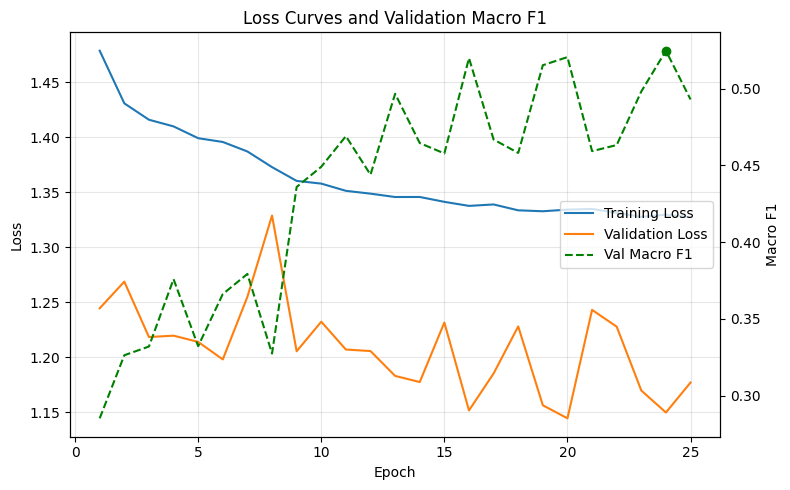

Final epoch model saved to cnn_model.pth
Loaded cnn_best_model.pth for final evaluation (best epoch: 24, macro F1: 0.5247).


  Val  :   0%|          | 0/577 [00:00<?, ?it/s]

               precision    recall  f1-score   support

        No DR       0.91      0.90      0.90     13472
         Mild       0.19      0.32      0.24      1320
     Moderate       0.73      0.40      0.52      2752
       Severe       0.28      0.63      0.39       465
Proliferative       0.63      0.53      0.58       449

     accuracy                           0.77     18458
    macro avg       0.55      0.56      0.52     18458
 weighted avg       0.81      0.77      0.78     18458

Macro F1: 0.5247  |  Quadratic Weighted Kappa: 0.7735
Confusion matrix:
[[12070  1140   134    83    45]
 [  746   421   128    21     4]
 [  465   607  1108   516    56]
 [   13    21   100   294    37]
 [   10    18    46   136   239]]

--- Source: 2015 (crowd-graded)  (n=17726)  macro F1=0.5302  QWK=0.7599 ---
               precision    recall  f1-score   support

        No DR       0.91      0.89      0.90     13111
         Mild       0.18      0.32      0.23      1246
     Moderate       0

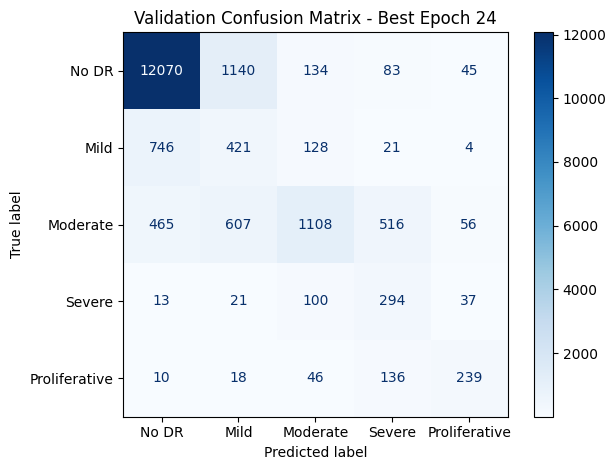

Training complete. Best validation macro F1: 0.5247 (epoch 24).


In [19]:
if MODEL_TYPE == "cnn":
    net = DeepCNN()
    num_epochs, lr, img_size = 25, 3e-4, IMG_SIZE
elif MODEL_TYPE == "resnet":
    net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    net.fc = nn.Linear(net.fc.in_features, 5)
    # Pretrained ResNet expects ImageNet-style 224 inputs.
    num_epochs, lr, img_size = 10, 1e-4, 224
else:
    raise ValueError(f"Unknown MODEL_TYPE: {MODEL_TYPE!r}. Use 'cnn' or 'resnet'.")

print(f"Training MODEL_TYPE={MODEL_TYPE} for {num_epochs} epochs at lr={lr}, img_size={img_size}\n")
model, history = train(net, num_epochs=num_epochs, lr=lr, img_size=img_size)